# Walk-Forward Analysis

## Objective

This notebook evaluates strategy robustness using walk-forward validation.

Instead of optimizing a strategy on the entire dataset, the framework:

1. Uses historical data for training.
2. Optimizes strategy parameters.
3. Tests the selected parameters on unseen data.
4. Repeats the process through time.

This approach reduces overfitting and provides a more realistic estimate of strategy performance.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from app.data_loader import load_market_data
from app.indicators import build_indicators

from app.walk_forward import (
    walk_forward_analysis
)

In [5]:
df = load_market_data(
    "AAPL"
)

df = build_indicators(
    df
)

df.head()

Price,Close,High,Low,Open,Volume,SMA_50,SMA_200,EMA_50,RSI,MACD,MACD_SIGNAL,BB_HIGH,BB_LOW,BB_MIDDLE
Date,,,,,,,,,,,,,,
2015-01-02,24.192612,24.659514,23.754475,24.648449,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,23.513273,23.772171,23.152585,23.575232,263188400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,23.842978,23.942553,23.610632,23.721273,160423600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,24.759089,24.816622,24.053203,24.170483,237458000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Walk-Forward Configuration

The strategy is evaluated using rolling windows.

Example:

Training:
2015 - 2018

Testing:
2018 - 2019


The window then moves forward one year.

In [6]:
train_periods = [
    ("2015-2018", "2018-2019"),
    ("2016-2019", "2019-2020"),
    ("2017-2020", "2020-2021"),
    ("2018-2021", "2021-2022"),
    ("2019-2022", "2022-2023"),
    ("2020-2023", "2023-2024"),
    ("2021-2024", "2024-2025"),
    ("2022-2025", "2025-2026")
]


train_periods

[('2015-2018', '2018-2019'),
 ('2016-2019', '2019-2020'),
 ('2017-2020', '2020-2021'),
 ('2018-2021', '2021-2022'),
 ('2019-2022', '2022-2023'),
 ('2020-2023', '2023-2024'),
 ('2021-2024', '2024-2025'),
 ('2022-2025', '2025-2026')]

In [8]:
results = walk_forward_analysis(
    df
)

results


            Training:
            2015-2018

            Testing:
            2018-2019
            

            Training:
            2016-2019

            Testing:
            2019-2020
            

            Training:
            2017-2020

            Testing:
            2020-2021
            

            Training:
            2018-2021

            Testing:
            2021-2022
            

            Training:
            2019-2022

            Testing:
            2022-2023
            

            Training:
            2020-2023

            Testing:
            2023-2024
            

            Training:
            2021-2024

            Testing:
            2024-2025
            

            Training:
            2022-2025

            Testing:
            2025-2026
            


,Train Period,Test Period,Fast SMA,Slow SMA,Return,Sharpe,Drawdown
0,2015-2018,2018-2019,70,200,-0.288174,-2.049537,-0.338471
1,2016-2019,2019-2020,20,100,0.604309,3.362222,-0.092471
2,2017-2020,2020-2021,20,100,0.679987,2.267438,-0.203756
3,2018-2021,2021-2022,70,300,0.000000,0.000000,0.000000
4,2019-2022,2022-2023,50,150,-0.034369,-0.231140,-0.154378
5,2020-2023,2023-2024,50,100,-0.018237,-0.111216,-0.134614
6,2021-2024,2024-2025,50,100,0.176773,1.368147,-0.117494
7,2022-2025,2025-2026,30,200,0.036652,0.729455,-0.053181


In [ ]:
results.describe()

In [9]:
average_results = pd.DataFrame({

    "Metric":[
        "Average Return",
        "Average Sharpe",
        "Average Drawdown"
    ],

    "Value":[

        results["Return"].mean(),

        results["Sharpe"].mean(),

        results["Drawdown"].mean()

    ]

})


average_results

,Metric,Value
0,Average Return,0.144618
1,Average Sharpe,0.666921
2,Average Drawdown,-0.136796


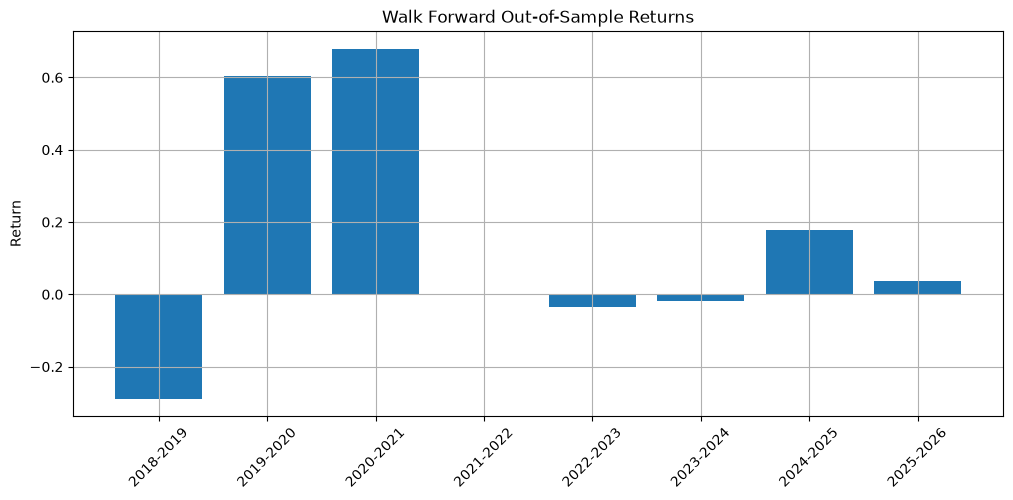

In [10]:
plt.figure(figsize=(12,5))

plt.bar(
    results["Test Period"],
    results["Return"]
)

plt.xticks(
    rotation=45
)

plt.title(
    "Walk Forward Out-of-Sample Returns"
)

plt.ylabel(
    "Return"
)

plt.grid()

plt.show()

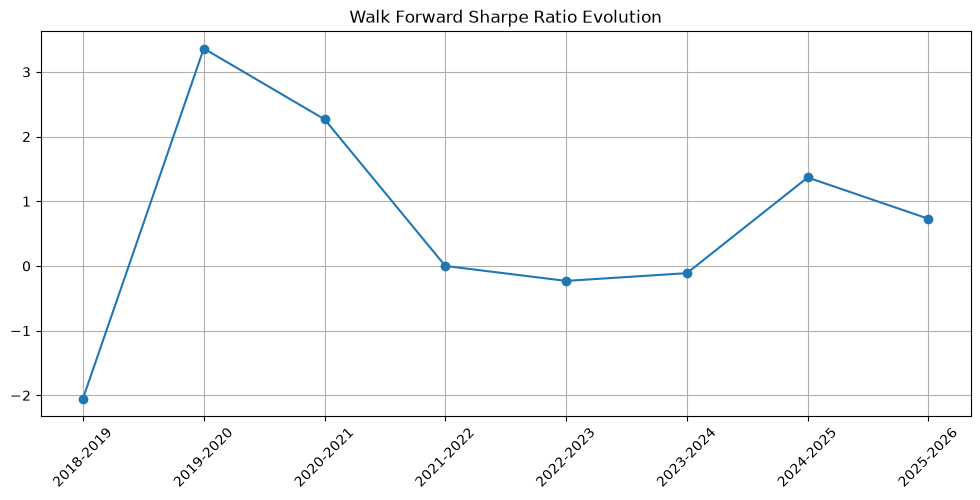

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
    results["Test Period"],
    results["Sharpe"],
    marker="o"
)


plt.xticks(
    rotation=45
)


plt.title(
    "Walk Forward Sharpe Ratio Evolution"
)


plt.grid()

plt.show()

# Conclusions

The walk-forward analysis demonstrates the importance of out-of-sample validation.

Key observations:

- Strategy performance varies across market regimes.
- Optimized parameters are not always stable.
- Risk-adjusted performance is more important than absolute return.
- Walk-forward testing provides a more realistic evaluation compared to full-period optimization.

The results support the use of portfolio diversification across multiple strategies.